In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

from sklearn.preprocessing import LabelEncoder,StandardScaler

from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
df = pd.read_csv("Mall_Customers.csv")
print('Dataset loaded!')

Dataset loaded!


In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df.shape

(200, 5)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [13]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [15]:
df.duplicated().sum()

0

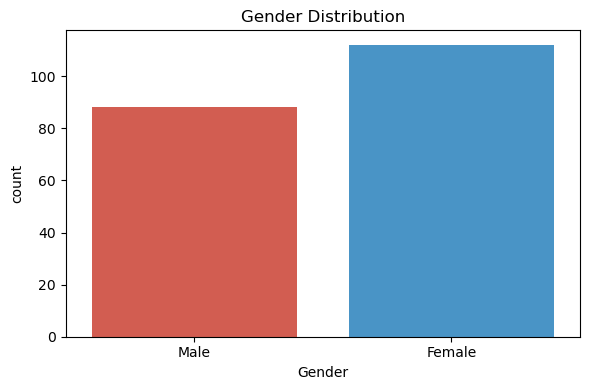

In [19]:
# Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, palette=['#e74c3c', '#3498db'])
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

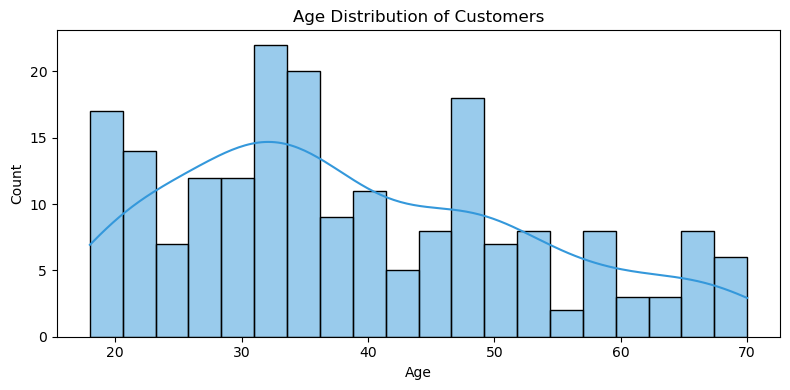

In [23]:
# Age Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='#3498db')
plt.title('Age Distribution of Customers')
plt.tight_layout()
plt.show()

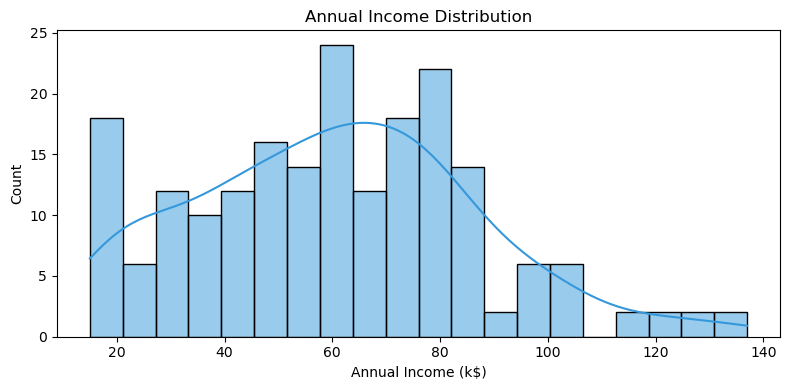

In [29]:
# Annual Income Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='#3498db')
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.tight_layout()
plt.show()

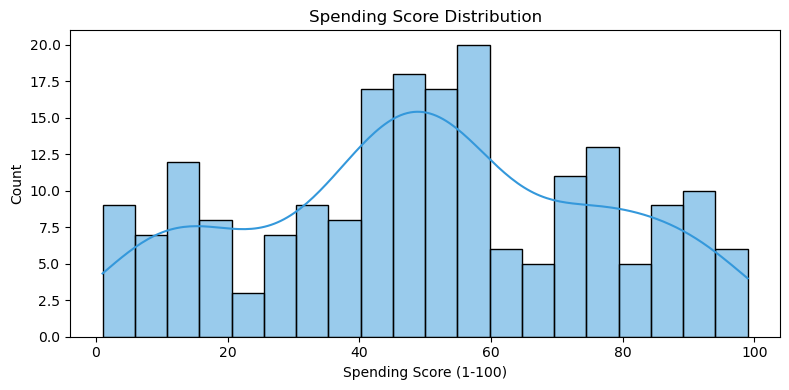

In [33]:
# Spending Score Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='#3498db')
plt.title('Spending Score Distribution')
plt.tight_layout()
plt.show()

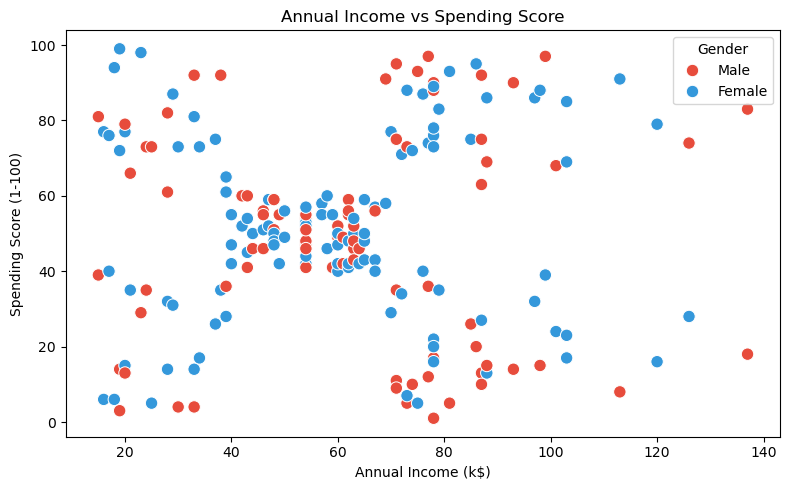

In [35]:
# Income vs Spending Score
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Gender', data=df, palette=['#e74c3c', '#3498db'], s=80)
plt.title('Annual Income vs Spending Score')
plt.tight_layout()
plt.show()

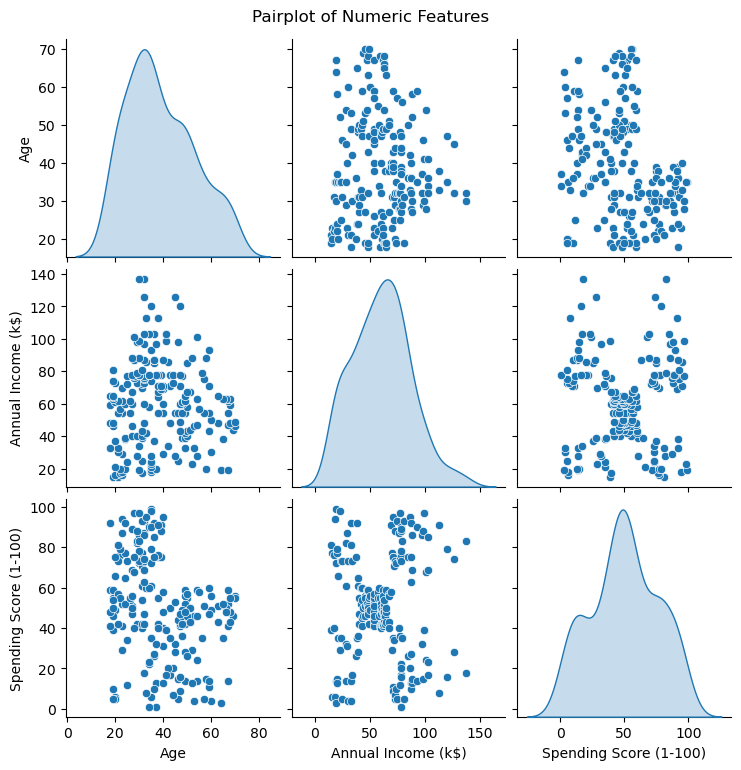

In [37]:
# Pairplot
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']], diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

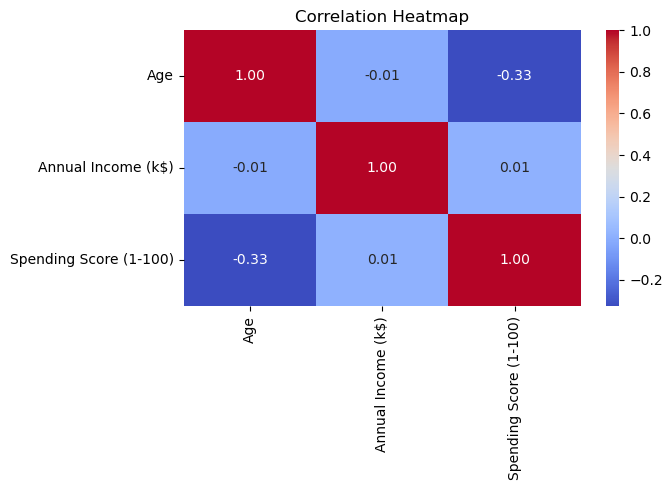

In [43]:
# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [49]:
# Encode Gender
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])  # Female=0, Male=1


In [51]:
# Features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [53]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features selected and scaled!')
print('Shape:', X_scaled.shape)

Features selected and scaled!
Shape: (200, 3)


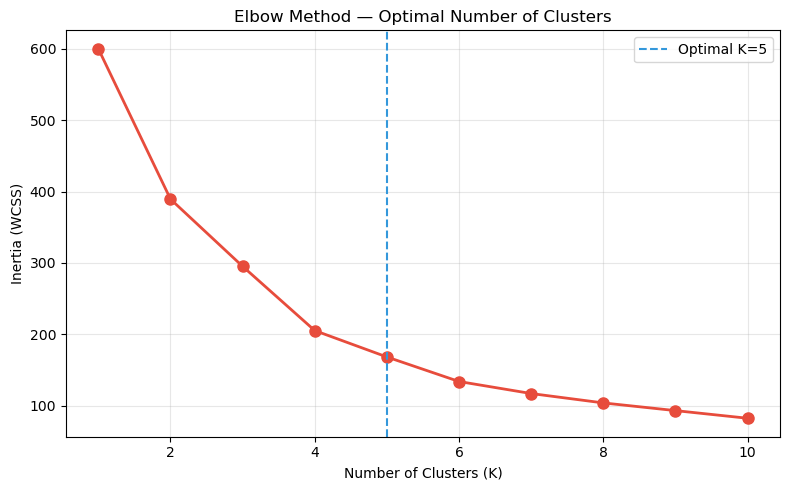

In [55]:
#Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='#e74c3c', linewidth=2, markersize=8)
plt.axvline(x=5, color='#3498db', linestyle='--', label='Optimal K=5')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('K-Means Clustering Done!')
print('\nCluster Distribution:')
print(df['Cluster'].value_counts().sort_index())

K-Means Clustering Done!

Cluster Distribution:
Cluster
0    20
1    54
2    40
3    39
4    47
Name: count, dtype: int64


In [59]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded,Cluster
0,1,Male,19,15,39,1,1
1,2,Male,21,15,81,1,1
2,3,Female,20,16,6,0,0
3,4,Female,23,16,77,0,1
4,5,Female,31,17,40,0,1


In [67]:
score = silhouette_score(
    X_scaled,
    df['Cluster']
)

print(score)

0.41664341513732767


In [73]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print('PCA Explained Variance Ratio:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%')

(200, 2)
PCA Explained Variance Ratio:
  PC1: 44.27%
  PC2: 33.31%
  Total: 77.57%


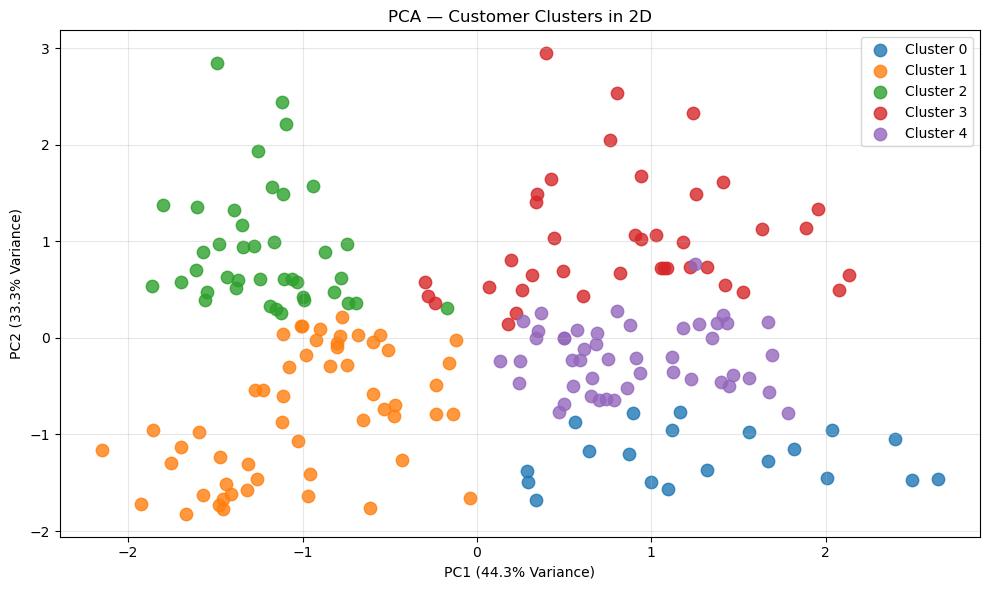

In [81]:
plt.figure(figsize=(10, 6))
for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                 label=f'Cluster {i}', s=80, alpha=0.8)

plt.title('PCA — Customer Clusters in 2D')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
cluster_analysis = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


## Cluster Interpretation

The average values of Age, Annual Income and Spending Score were analyzed to understand the characteristics of each customer segment.

### Cluster 0
- Older customers
- Low income
- Very low spending
- Customer Type: Budget-Conscious Customers

### Cluster 1
- Young customers
- Medium income
- High spending
- Customer Type: Young Active Shoppers

### Cluster 2
- High income
- Highest spending
- Customer Type: VIP Customers

### Cluster 3
- High income
- Very low spending
- Customer Type: Potential Customers

### Cluster 4
- Older customers
- Average income
- Average spending
- Customer Type: Stable Customers

## Marketing Strategies

### Cluster 0
Offer discounts, seasonal sales and affordable products.

### Cluster 1
Provide loyalty programs, student discounts and app-based promotions.

### Cluster 2
Offer VIP memberships, premium products and exclusive events.

### Cluster 3
Use targeted promotions and personalized marketing campaigns.

### Cluster 4
Focus on customer retention, referral rewards and loyalty benefits.

## Conclusion

Customer segmentation was successfully performed using K-Means clustering.

Five customer groups were identified based on annual income and spending behavior.

PCA visualization showed clear separation between customer segments.

The Silhouette Score indicated acceptable clustering performance.

These customer segments can help businesses design targeted marketing campaigns and improve customer retention.